# Tarea: Análisis Visual de Ventas de Tienda de Conveniencia

### **Equipo:** Cristofher Godoy C., Daniela Pinto C.; Isabel Vergara R.
### **Grupo:** 15
### **Curso:** Visualización de Datos en Python

## Descripción del Caso

Una cadena de tiendas de conveniencia quiere analizar sus ventas y el comportamiento de los clientes para mejorar su estrategia de marketing. Para ello, han recopilado un conjunto de datos que incluye información sobre las ventas, los productos y los clientes. Su misión será usar las técnicas de visualización de datos aprendidas para analizar y presentar los resultados de este conjunto de datos.

## Indicaciones Generales

1.  **Dataset:** Utilizarán el dataset "Supermarket Sales" disponible en Kaggle (data.csv).
2.  **Entorno:** Trabajen según las indicaciones de este notebook.
3.  **Colaboración:** Esta es una tarea grupal. Asegúrense de coordinar el trabajo.
4.  **Streamlit:** Se requiere crear un dashboard interactivo usando la librería Streamlit. Deberán escribir y ejecutar su código como script the python (archivo .py), pero deben también escribir el código en una celda dentro de éste jupyter notebook para su revisión.
5.  **Pensamiento Crítico:** Incluyan reflexiones y justificaciones para sus elecciones de visualización y análisis.
6.  **Entrega:** Entreguen este notebook completado según las indicaciones.

## 1. Selección de Variables y desarrollo de Análisis


a.  Examinen el conjunto de datos proporcionado (`df.info()`, `df.describe()`, `df.columns`).

b.  Identifiquen y **justifiquen** las variables que consideren más relevantes para un análisis significativo del comportamiento de ventas y clientes. 

Las variables más reelevantes para un análisis del comportamiento de ventas son:
- Quantity: La cantidad compra indica la demanada de productos y patrones de compra.
- Unit price: El precio unitario permite evaluar a estrategia de precio y rentabilidad.
- Total: El monto total de compra permite ver el gasto de los clientes y el ticket promedio.
- Gross income: el ingreso bruto permite ver la rentabilidad de cada venta.

Las variables más reelevantes para un análisis del comportamiento de clientes son:
- City: Permite identificar comportamiento según ubicación geográfica de las ventas.
- Gender: el género permite identificar si hay preferencias de compra.
- Customer type: con el tipo de cliente es posible ver diferencia entre clientes ocacionales y leales.

c.  Reflexionen sobre la importancia de cada variable seleccionada en el contexto del caso de estudio (¿Qué preguntas de negocio pueden ayudar a responder?).

Algunas preguntas de negocio que se pueden responder con estas variables son:
- ¿Qué productos son más demandados y cuándo?
- ¿Cómo es el comportamiento de gasto según el tipo de cliente?
- ¿Hay diferencia entre el comportamiento por ciudad o género?
- ¿Hay relación entre la demanda de productos y el precio unitario?



In [41]:
# Obtener información sobre las columnas y tipos de datos
df.info()

# Describir estadísticas básicas de las variables numéricas
df.describe()

# Mostrar nombres de las columnas disponibles
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Tipo de Cliente          1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Gasto Total              1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## Análisis Requeridos:

1.  **Evolución de las Ventas Totales:**
    *   **Objetivo:** Mostrar cómo han variado las ventas totales (`Total`) a lo largo del tiempo (`Date`).

2.  **Ingresos por Línea de Producto:**
    *   **Objetivo:** Comparar los ingresos (`Total`) generados por cada `Product line`.

3.  **Distribución de la Calificación de Clientes:**
    *   **Objetivo:** Analizar la distribución de las calificaciones (`Rating`) de los clientes.

4.  **Comparación del Gasto por Tipo de Cliente:**
    *   **Objetivo:** Comparar la distribución del gasto total (`Total`) entre clientes `Member` y `Normal`.

5.  **Relación entre Costo y Ganancia Bruta:**
    *   **Objetivo:** Visualizar la relación entre el costo de bienes vendidos (`cogs`) y el ingreso bruto (`gross income`).

6.  **Métodos de Pago Preferidos:**
    *   **Objetivo:** Identificar los métodos de pago (`Payment`) más frecuentes.

7.  **Análisis de Correlación Numérica:**
    *   **Objetivo:** Explorar relaciones lineales entre variables numéricas (`Unit price`, `Quantity`, `Tax 5%`, `Total`, `cogs`, `gross income`, `Rating`).

8.  **Composición del Ingreso Bruto por Sucursal y Línea de Producto:**
    *   **Objetivo:** Mostrar la contribución de cada `Product line` al `gross income` dentro de cada `Branch`.

---

## Requisitos Adicionales:
*   Implementación en Streamlit.
*   Gráficos claros (títulos, etiquetas).
*   Interactividad (filtros) donde sea apropiado.
*   Aplicación de buenas prácticas de visualización (claridad).

**1. Evolución de las Ventas Totales**

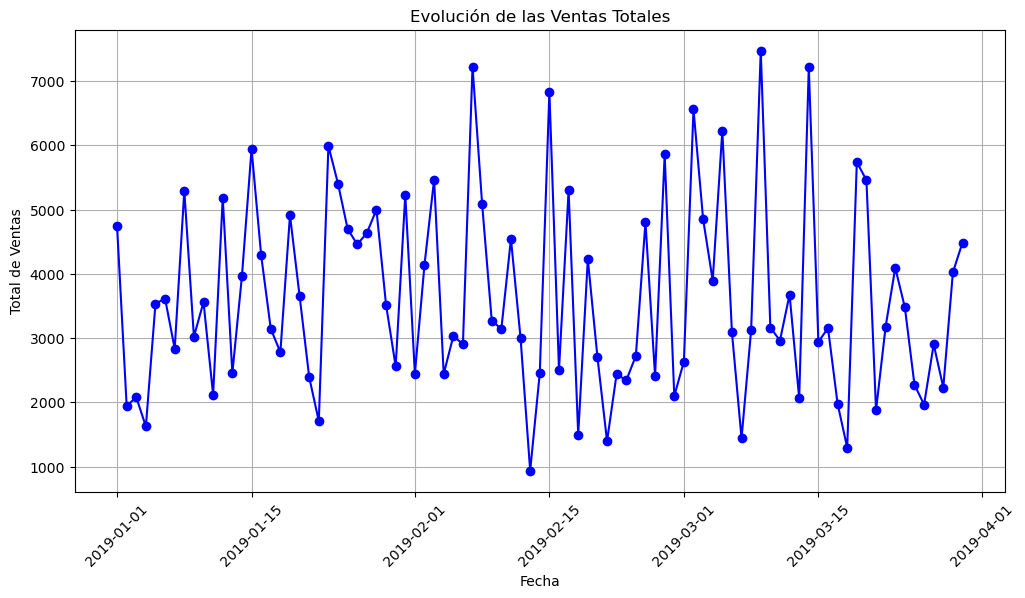

In [13]:
df = pd.read_csv("data.csv")
df["Date"] = pd.to_datetime(df["Date"])  # Convertir a formato de fecha

ventas_por_fecha = df.groupby("Date")["Total"].sum()

plt.figure(figsize=(12, 6))
plt.plot(ventas_por_fecha.index, ventas_por_fecha.values, marker="o", linestyle="-", color="b")
plt.title("Evolución de las Ventas Totales")
plt.xlabel("Fecha")
plt.ylabel("Total de Ventas")
plt.xticks(rotation=45)
plt.grid()
plt.show()

En este gráfico se puede observar las fluctuaciones de ventas diarias, mostrando que en la segunda quincena de los meses de enero a abril hay alzas de ventas superando los 7000.-

**2. Ingreso por Línea de Producto**

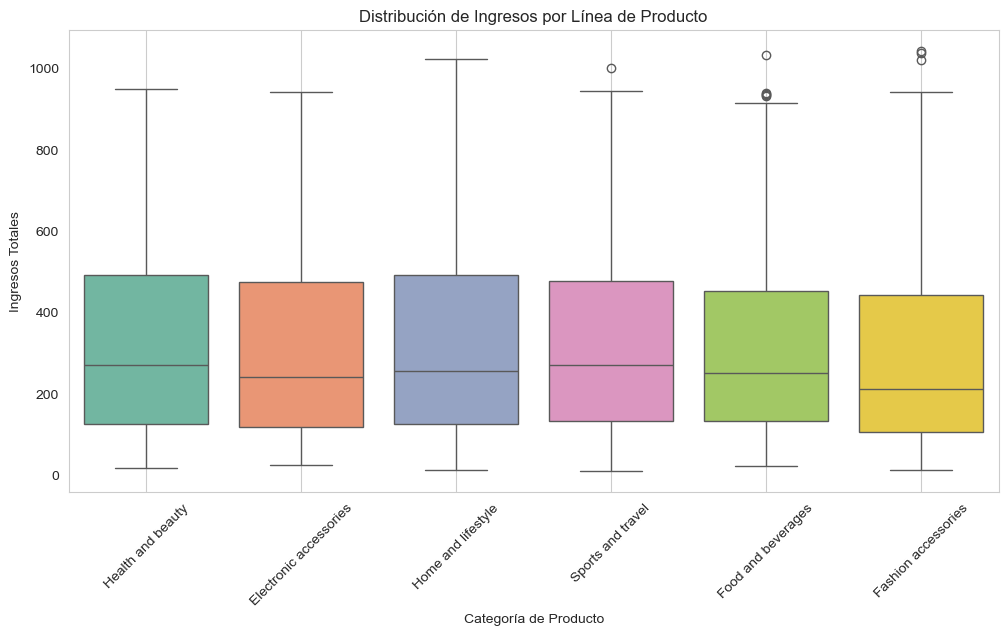

In [54]:
# Cargar el conjunto de datos
df = pd.read_csv("data.csv")

# Configurar el estilo de los gráficos
sns.set_style("whitegrid")

# Crear el gráfico de ingresos por línea de producto
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Product line", y="Total", hue="Product line", palette="Set2", legend=False)

# Mejorar la presentación
plt.xticks(rotation=45)
plt.title("Distribución de Ingresos por Línea de Producto")
plt.xlabel("Categoría de Producto")
plt.ylabel("Ingresos Totales")
plt.grid()

# Mostrar el gráfico
plt.show()

En este gráfico podemos ver la distrubución de ingresos por línea de producto, donde podemos identificar categorias más rentables, como "Food and beverages" que tiene ingresos elevados y consistentes, siendo una categoria atractiva para aumentar la inversión.

**3. Distribución de la Calificación de clientes**

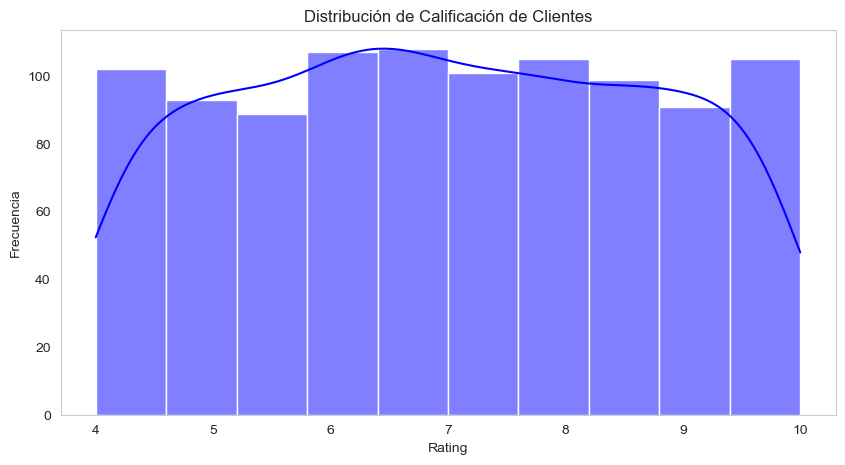

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Rating"], bins=10, kde=True, color="blue")
plt.title("Distribución de Calificación de Clientes")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

En este gráfico de "Distribución de Calificaciones de Clientes" muestra las calificaciones en un rango de 4 a 10. Podemos ver que hay oportunidades de mejora ya que un grupo importante de clientes que calificó en 4. Es importante mencionar que la mayoría de los clientes está satisfecho.

**4. Comparación del Gasto por Tipo de Cliente**

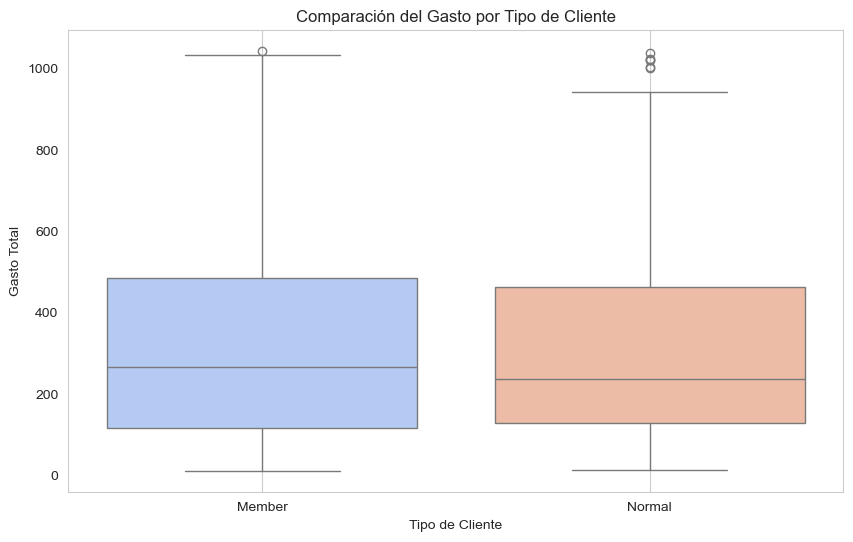

In [43]:
# Cargar datos
df = pd.read_csv("data.csv")

# Renombrar columnas para mayor claridad
df.rename(columns={
    "Customer type": "Tipo de Cliente",
    "Total": "Gasto Total"
}, inplace=True)

# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear el gráfico
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Tipo de Cliente", y="Gasto Total", hue="Tipo de Cliente", palette="coolwarm", legend=False)

# Mejorar la presentación
plt.title("Comparación del Gasto por Tipo de Cliente")
plt.xlabel("Tipo de Cliente")
plt.ylabel("Gasto Total")
plt.grid()

# Mostrar el gráfico
plt.show()

En este boxplot podemos ver la comparación de gasto total entre clientes Membery Normales. Los clientes Member tienen una mediana de gastos más alto en relación a los clientes Normales y tienes una mayor dispersión, lo que muestra que algunos clientes gastan significativamente más que otros.

**5. Relación entre Costo y Ganancia Bruta**

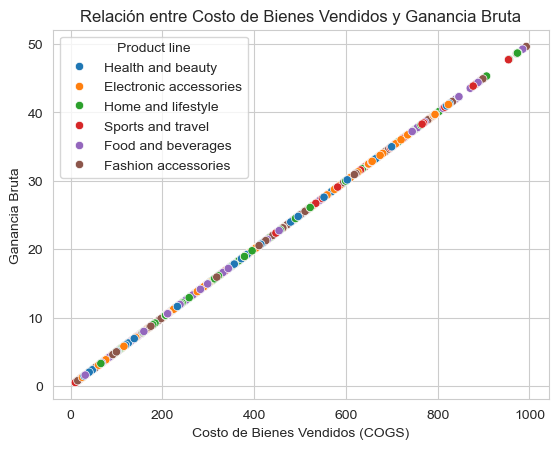

In [58]:
sns.scatterplot(x=df["cogs"], y=df["gross income"], hue=df["Product line"])
plt.title("Relación entre Costo de Bienes Vendidos y Ganancia Bruta")
plt.xlabel("Costo de Bienes Vendidos (COGS)")
plt.ylabel("Ganancia Bruta")
plt.show()

En este gráfico podemos ver que los costos y ganancias están alineados, visualizando una relación positiva a medida que el costo de los bienes vendidos aumenta, la ganancia Bruta también lo hace proporcionalmente.

In [14]:
# Diccionario de traducción
traducir_pago = {
    "Cash": "Efectivo",
    "Credit card": "Tarjeta de Crédito",
    "Ewallet": "Billetera Electrónica"
}

# Aplicar la traducción a la columna Payment
df["Método de Pago"] = df["Payment"].map(traducir_pago)

# Aplicar la traducción
df["Método de Pago"] = df["Payment"].map(traducir_pago)

# Crear gráfico con nombres en español
fig = px.bar(df, x="Método de Pago", y="Total", color="Método de Pago",
             title="Métodos de Pago Preferidos")

# Mostrar el gráfico
fig.show()

En este gráfico podemos ver que los medios de pago "efectivo" y "tarjeta de crédito" es donde se generan los mayores ingresos totales y son los más utilizados. El medio de pago "Billetera electrónica"tiene ingresos registrados pero al compararlo es menor a los otros 3 medios de pagos. 

**7. Análisis de Correlación Numérica**

<module 'matplotlib.pyplot' from 'c:\\Users\\Gateway\\anaconda3\\envs\\viz\\Lib\\site-packages\\matplotlib\\pyplot.py'>

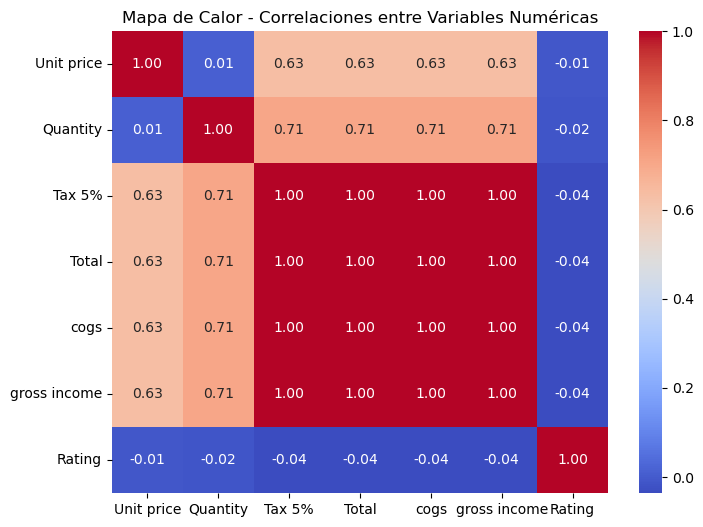

In [8]:
# Calcular la matriz de correlación
correlation_matrix = df[["Unit price", "Quantity", "Tax 5%", "Total", "cogs", "gross income", "Rating"]].corr()

# Crear el mapa de calor de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Mejorar la presentación del gráfico
plt.title("Mapa de Calor - Correlaciones entre Variables Numéricas")
plt

En este mapa de calor poder ver que entre el "total" y cantidad" existe una alta correlación positiva, por lo que, al aumentar la cantidad de productos comprados, el monto total de la compra también aumenta proporcionalmente. 
Entre los Ingresos Brutos y el costo de venta hay una alta correlación positiva, lo que indica que los costos de los bienes vendidos impacta directamente en los ingresos brutos.
La variable rating presentan una baja correlación cpn el precio unitario y total, lo que siguere que los clientes califican su experiencia más allá del precio o monto total de la compra.



**8. Composición del Ingreso Bruto por Sucursal y Línea de Producto**

In [15]:
# Diccionario de traducción para sucursales y líneas de producto
traducir_sucursal = {
    "A": "Sucursal A",
    "B": "Sucursal B",
    "C": "Sucursal C"
}

traducir_productos = {
    "Health and beauty": "Salud y Belleza",
    "Electronic accessories": "Accesorios Electrónicos",
    "Home and lifestyle": "Hogar y Estilo de Vida",
    "Sports and travel": "Deportes y Viajes",
    "Food and beverages": "Alimentos y Bebidas",
    "Fashion accessories": "Accesorios de Moda"
}

# Aplicar la traducción a las columnas correspondientes
df["Sucursal"] = df["Branch"].map(traducir_sucursal)
df["Categoría de Producto"] = df["Product line"].map(traducir_productos)


# Crear gráfico con nombres traducidos
fig = px.sunburst(df, path=["Sucursal", "Categoría de Producto"], values="gross income",
                  title="Distribución del Ingreso Bruto por Sucursal y Categoría de Producto")

# Mostrar el gráfico
fig.show()


Este gráfico de sunburst permite visualizar la distribución de ingreso bruto por sucursal y línea de producto, con las respectivas categorias que generan más gananciaas en cada ubicación. Podemos ver que la sucursal A tiene mayor proporción de ingresos brutos, lo que indica que genera más ganancias en comparación con las otras. En cada sucursal vemos las líneas de productos con mayores intresos, donde el que tiene mayor participación es Alimentos y Bebidas, por lo que, es una categoria clave para las ventas.  

## 2. Integración en un Dashboard (Streamlit)

a.  Utilizando Streamlit, integren **algunas** de sus visualizaciones y hallazgos clave en un dashboard interactivo.

b.  Asegúrense de que el dashboard sea intuitivo y bien organizado (usen títulos, texto explicativo, widgets interactivos como sliders o selectores para filtrar datos).

c.  Reflexionen sobre cómo la interactividad del dashboard mejora la experiencia del usuario y el proceso de toma de decisiones basado en los datos presentados.

**Instrucciones:**
1.  Escriban el código completo de su aplicación Streamlit en la celda de código de abajo.
2.  Copien ese código a un archivo de texto simple llamado `dashboard_tarea.py` (o el nombre que prefieran).
3.  Abran una terminal o Anaconda Prompt, naveguen a la carpeta donde guardaron el archivo.
4.  Ejecuten el comando: `streamlit run dashboard_tarea.py`
5.  Interactúen con su dashboard en el navegador.
6.  **Importante:** En la celda de Markdown siguiente, describan su dashboard, qué visualizaciones incluye, qué interacciones permite, y adjunten el código de su script de python.

In [45]:
# --- Describan su Dashboard (Gráficos Utilizados y Justificación de su uso) --- 

''' ESCRIBIR AQUÍ SU DESCRIPCIÓN DEL DASHBOARD'''

' ESCRIBIR AQUÍ SU DESCRIPCIÓN DEL DASHBOARD'

In [46]:
# --- CÓDIGO PARA dashboard_tarea_grupo_X.py --- 
# (Este bloque NO se ejecuta directamente en Jupyter)

''' PEGAR A CONTINUACIÓN EL CÓDIGO DEL DASHBOARD '''

' PEGAR A CONTINUACIÓN EL CÓDIGO DEL DASHBOARD '

import streamlit as st
import pandas as pd
import plotly.express as px

# Cargar datos con caché
@st.cache_data
def cargar_datos():
    df = pd.read_csv("data.csv")
    df["Fecha"] = pd.to_datetime(df["Date"])
    df["Año"] = df["Fecha"].dt.year
    df["Mes"] = df["Fecha"].dt.month
    df["Día_Semana"] = df["Fecha"].dt.day_name()
    return df

df = cargar_datos()

# Verificar si el DataFrame está vacío
if df.empty:
    st.error("⚠ No se encontraron datos en 'data.csv'. Verifica el archivo.")
    st.stop()

# 🏠 **Barra lateral con filtros**
st.sidebar.header("📌 Filtros del Dashboard")

# Filtro de Año
anio_seleccionado = st.sidebar.selectbox("Selecciona el año:", sorted(df["Año"].unique()), key="select_anio")

# Filtro de Mes con nombres descriptivos
meses_nombres = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}
mes_seleccionado = st.sidebar.selectbox(
    "Selecciona el mes:", sorted(df[df["Año"] == anio_seleccionado]["Mes"].unique()), 
    format_func=lambda x: meses_nombres[x], key="select_mes"
)

# Filtrar datos por año y mes
df_filtrado = df[(df["Año"] == anio_seleccionado) & (df["Mes"] == mes_seleccionado)]

# 🏆 **Título del Dashboard**
st.title(f"📊 Dashboard de Ventas - {meses_nombres[mes_seleccionado]} {anio_seleccionado}")

# 📖 **Descripción**
st.markdown(f"Explora las tendencias de ventas para **{meses_nombres[mes_seleccionado]} de {anio_seleccionado}**.")

# 🔹 **Gráfico de Ingresos por Categoría de Producto**
st.subheader("🔹 Ingreso Bruto por Categoría de Producto")
fig_ingresos = px.bar(df_filtrado, x="Product line", y="gross income", color="Product line", title="Ingresos por Categoría")
st.plotly_chart(fig_ingresos)

# 💳 **Gráfico de Método de Pago**
st.subheader("💳 Distribución de Métodos de Pago")
fig_pago = px.pie(df_filtrado, names="Payment", values="Total", title="Método de Pago")
st.plotly_chart(fig_pago)

# 👥 **Gráfico de ventas por tipo de cliente**
if "Customer type" in df_filtrado.columns:
    st.subheader("👥 Distribución de Ventas por Tipo de Cliente")
    fig_clientes = px.pie(df_filtrado, names="Customer type", values="Total", title="Tipo de Cliente")
    st.plotly_chart(fig_clientes)

# 📅 **Gráfico de ingresos por día de la semana**
st.subheader("📅 Tendencia de Ingresos por Día de la Semana")
fig_dia = px.bar(df_filtrado, x="Día_Semana", y="gross income", color="Día_Semana", title="Ingresos por Día de la Semana")
st.plotly_chart(fig_dia)

# 🔍 **Conclusión**
st.markdown("""
✅ **Interactividad:** Filtra datos por mes y año para analizar tendencias específicas.  
✅ **Nuevas visualizaciones:** Ahora puedes explorar ingresos mensuales, clientes y rendimiento por días de la semana.  
✅ **Optimización:** La información ayuda a detectar patrones de compra y mejorar la toma de decisiones estratégicas.  
""")

# 3. Deployment

a.  Desplieguen su dashboard en Streamlit Cloud.

b.  Asegúrense de que el dashboard sea accesible públicamente.

c.  Proporcionen el enlace al dashboard desplegado en la celda de Markdown siguiente.

d.  Reflexionen sobre el proceso de despliegue y cualquier desafío que hayan enfrentado.


En el caso que no hayan podido deployar:

In [47]:
'''
Comentar si hubo problemas con el código o si no se ejecutó correctamente que les impidieron realizar el análisis completo y el deployment del dashboard.
'''

'\nComentar si hubo problemas con el código o si no se ejecutó correctamente que les impidieron realizar el análisis completo y el deployment del dashboard.\n'

En el caso que hayan podido deployar:

In [48]:
'''
Poner aquí la url de su dashboard en el servidor de Streamlit.
Ejemplo: https://share.streamlit.io/streamlit/demo-uber-nyc-pickups
'''

'\nPoner aquí la url de su dashboard en el servidor de Streamlit.\nEjemplo: https://share.streamlit.io/streamlit/demo-uber-nyc-pickups\n'

# 4. Conclusiones Generales

Reflexionen sobre el proceso de análisis y visualización. ¿Qué aprendieron sobre los datos de la tienda? ¿Qué limitaciones encontraron en los datos o en las técnicas de visualización? ¿Qué recomendaciones (basadas en los datos) podrían darle a la cadena de tiendas?

In [49]:
'''
Escriban acá su reflexión sobre el Dashboard.
'''

'\nEscriban acá su reflexión sobre el Dashboard.\n'

# 5. Referencias

Listar las fuentes utilizadas (dataset, bibliotecas principales, material de referencia adicional si aplica).

In [50]:
'''
Escriban aquí las referencias.
'''

'\nEscriban aquí las referencias.\n'

## NOTA FINAL:
### Asegúrense de sólo subir el jupyter notebook a la plataforma, con un formato del tipo: "Trabajo_Grupo_X.ipynb".
### No es necesario incluir el archivo .py del dashboard, pero sí el código dentro de este cuaderno en el apartado correspondiente.